In [12]:
import pandas as pd
from google.colab import drive
import os

# 1. Google Drive'ı Bağla (İzin ver penceresi açılacaktır, onaylayın)
drive.mount('/content/drive')

# 2. Dosya Yolunu Belirle
# Dosyanız Drive ana dizindeyse yol genellikle şöyledir:
file_path = "/content/drive/MyDrive/tum_veriler_temiz_birlesmis.csv"

# 3. Dosyayı Yükle
if os.path.exists(file_path):
    df = pd.read_csv(file_path)
    print(df.head())
else:
    print(f" Dosya bulunamadı: {file_path}")
    print("Lütfen dosyanın Google Drive'ınızın 'Drive'ım' (Ana Sayfa) kısmında olduğundan emin olun.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
  State  Mortality_Rate   Gender Race_Ethnicity   FIPS      Y_lat       X_lon  \
0    AK           348.8     Male          White   2068  63.678820 -149.960801   
1    CO           135.9   Female          White   8093  39.115616 -105.708698   
2    FL           126.5   Female          Asian  12131  30.655966  -86.157457   
3    GA           155.1   Female       Hispanic  13313  34.803854  -84.962112   
4    IA           168.0  Overall       Hispanic  19093  42.387689  -95.523143   

                       Georeference  Median_Income_2022  Edu_Bach_Pct_2019-23  \
0  POINT (-149.9608012 63.67881971)             90897.0             23.631990   
1  POINT (-105.7086982 39.11561621)             88020.0             38.826138   
2  POINT (-86.15745736 30.65596581)             78814.0             34.229875   
3  POINT (-84.96211184 34.80385386)             61680.0     

In [13]:
#  1. VERİ FİLTRELEME VE KONTROL

# 'GeographicLevel' sütunu var mı diye kontrol edelim
if 'GeographicLevel' in df.columns:
    # Sütun varsa filtreleme yap
    df_clean = df[df['GeographicLevel'] == 'County'].copy()
    print(f"✅ Filtreleme yapıldı. Sadece ilçe (County) verisi seçildi.")
else:
    # Sütun yoksa, veri zaten temizlenmiştir diye varsayıp devam et
    print("ℹ️ 'GeographicLevel' sütunu bulunamadı.")
    print("   Dosya adınız 'temiz_birlesmis' olduğu için bu filtreleme daha önce yapılmış olabilir.")
    df_clean = df.copy() # Filtreleme yapmadan kopyala

print(f"İşlem sonrası satır sayısı: {df_clean.shape[0]}")

# 2. GEREKSİZ SÜTUNLARI TEMİZLEME (Hata almamak için kontrol ederek silme)
cols_to_drop = ['GeographicLevel', 'DataSource', 'Class', 'Topic', 'Data_Value_Unit',
                'Data_Value_Type', 'Data_Value_Footnote_Symbol',
                'Data_Value_Footnote', 'StratificationCategory1',
                'Stratification1', 'TopicID', 'LocationID', 'LocationDesc']

# Sadece veri setinde gerçekten var olanları sil
existing_cols_to_drop = [col for col in cols_to_drop if col in df_clean.columns]
df_clean.drop(columns=existing_cols_to_drop, inplace=True)

print(f"\nTemizlik sonrası kalan sütun sayısı: {df_clean.shape[1]}")
print(df_clean.head())

ℹ️ 'GeographicLevel' sütunu bulunamadı.
   Dosya adınız 'temiz_birlesmis' olduğu için bu filtreleme daha önce yapılmış olabilir.
İşlem sonrası satır sayısı: 33030

Temizlik sonrası kalan sütun sayısı: 11
  State  Mortality_Rate   Gender Race_Ethnicity   FIPS      Y_lat       X_lon  \
0    AK           348.8     Male          White   2068  63.678820 -149.960801   
1    CO           135.9   Female          White   8093  39.115616 -105.708698   
2    FL           126.5   Female          Asian  12131  30.655966  -86.157457   
3    GA           155.1   Female       Hispanic  13313  34.803854  -84.962112   
4    IA           168.0  Overall       Hispanic  19093  42.387689  -95.523143   

                       Georeference  Median_Income_2022  Edu_Bach_Pct_2019-23  \
0  POINT (-149.9608012 63.67881971)             90897.0             23.631990   
1  POINT (-105.7086982 39.11561621)             88020.0             38.826138   
2  POINT (-86.15745736 30.65596581)             78814.0           

In [ ]:
#  1. EKSİK VERİ KONTROLÜ
print("\nEksik Veri Kontrolü (Temizlemeden Önce):")
print(df_clean.isnull().sum())

df_clean.dropna(subset=['Mortality_Rate'], inplace=True)
print(f"\n'Mortality_Rate' sütununda eksik olan satırlar silindi. Yeni satır sayısı: {df_clean.shape[0]}")

#  2. VERİ TİPİ KONTROLÜ VE DÖNÜŞÜM
print("\nVeri Tipi Kontrolü:")
df_clean.info()

if df_clean['Mortality_Rate'].dtype == 'object':
    df_clean['Mortality_Rate'] = pd.to_numeric(df_clean['Mortality_Rate'], errors='coerce')
    df_clean.dropna(subset=['Mortality_Rate'], inplace=True)


Eksik Veri Kontrolü (Temizlemeden Önce):
State                   0
Mortality_Rate          0
Gender                  0
Race_Ethnicity          0
FIPS                    0
Y_lat                   0
X_lon                   0
Georeference            0
Median_Income_2022      0
Edu_Bach_Pct_2019-23    0
Poverty_Pct_2023        0
dtype: int64

'Mortality_Rate' sütununda eksik olan satırlar silindi. Yeni satır sayısı: 33030

Veri Tipi Kontrolü:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33030 entries, 0 to 33029
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   State                 33030 non-null  object 
 1   Mortality_Rate        33030 non-null  float64
 2   Gender                33030 non-null  object 
 3   Race_Ethnicity        33030 non-null  object 
 4   FIPS                  33030 non-null  int64  
 5   Y_lat                 33030 non-null  float64
 6   X_lon                 33030 non-nu

In [ ]:
#  FIPS KODU STANDARTLAŞTIRMASI
df_clean['FIPS'] = df_clean['FIPS'].astype(str)

df_clean['FIPS'] = df_clean['FIPS'].str.zfill(5)

print("\nFIPS kodları 5 haneli metin formatına dönüştürüldü (örn: '01001').")
# Dönüştürmenin sonucunu kontrol etmek için ilk satırları görüntüleme
print(df_clean[['State', 'FIPS', 'Gender', 'Race_Ethnicity']].head())


FIPS kodları 5 haneli metin formatına dönüştürüldü (örn: '01001').
  State   FIPS   Gender Race_Ethnicity
0    AK  02068     Male          White
1    CO  08093   Female          White
2    FL  12131   Female          Asian
3    GA  13313   Female       Hispanic
4    IA  19093  Overall       Hispanic


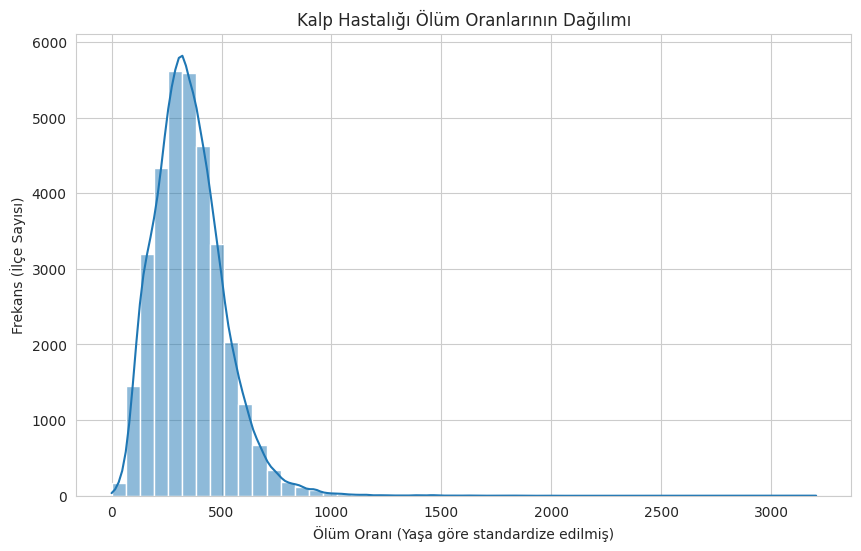

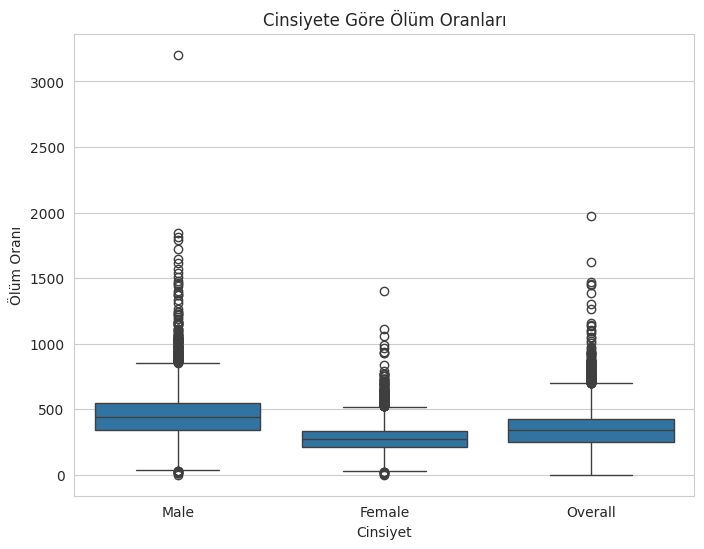

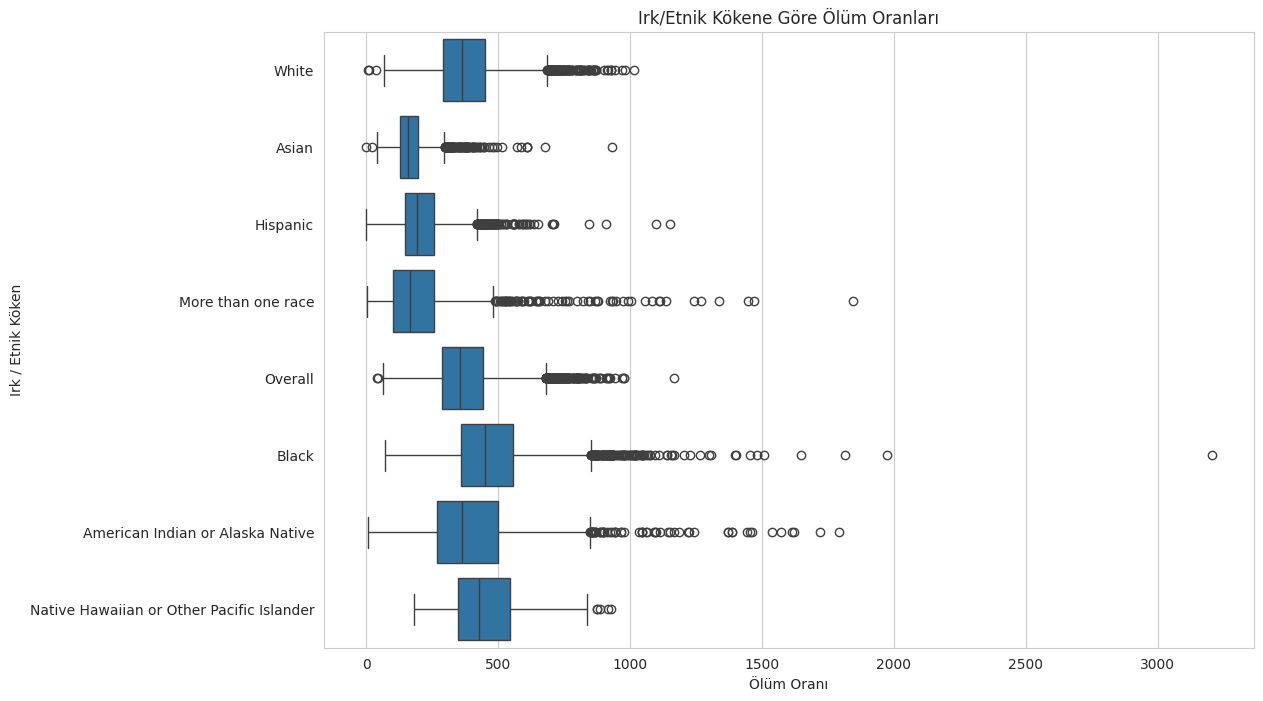

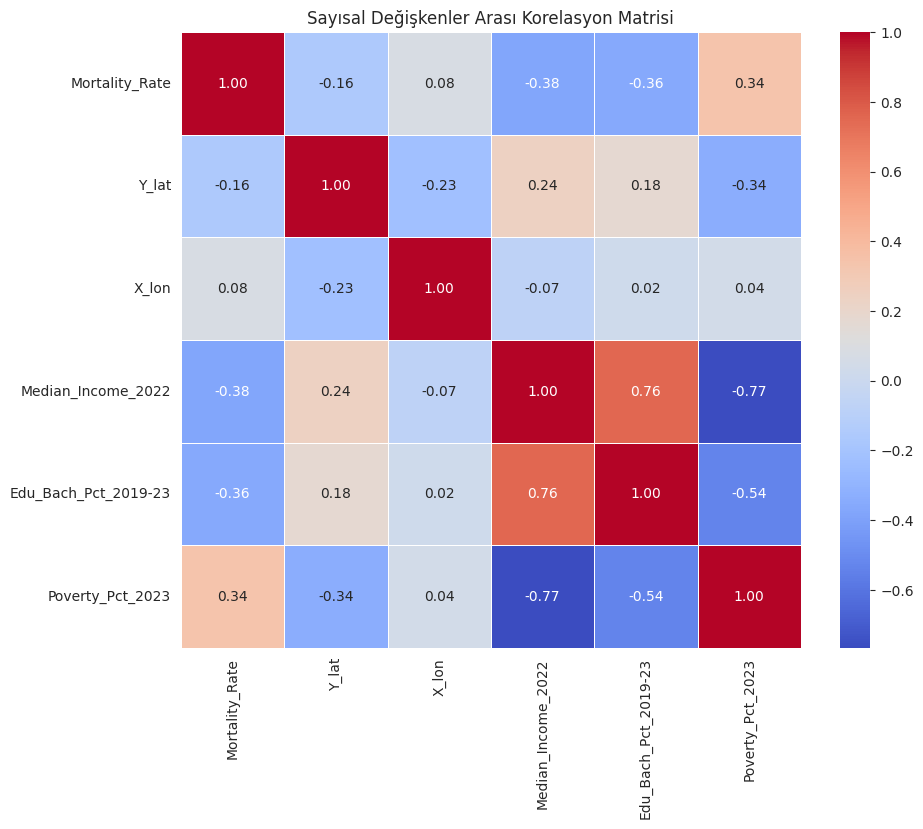

In [ ]:
# --- EKSİK OLAN KÜTÜPHANELERİ İÇE AKTARMA ---
import numpy as np  # <-- "np is not defined" hatasını çözen satır budur
import seaborn as sns
import matplotlib.pyplot as plt

# Görselleştirme Ayarları
sns.set_style("whitegrid")

# 1. Hedef Değişkenin (Mortality_Rate) Dağılımı
plt.figure(figsize=(10, 6))
sns.histplot(df_clean['Mortality_Rate'], kde=True, bins=50)
plt.title('Kalp Hastalığı Ölüm Oranlarının Dağılımı')
plt.xlabel('Ölüm Oranı (Yaşa göre standardize edilmiş)')
plt.ylabel('Frekans (İlçe Sayısı)')
plt.show()

# 2. Cinsiyete Göre Ölüm Oranları
plt.figure(figsize=(8, 6))
sns.boxplot(data=df_clean, x='Gender', y='Mortality_Rate')
plt.title('Cinsiyete Göre Ölüm Oranları')
plt.xlabel('Cinsiyet')
plt.ylabel('Ölüm Oranı')
plt.show()

# 3. Etnik Köken/Irka Göre Ölüm Oranları
plt.figure(figsize=(12, 8))
sns.boxplot(data=df_clean, y='Race_Ethnicity', x='Mortality_Rate', orient='h')
plt.title('Irk/Etnik Kökene Göre Ölüm Oranları')
plt.xlabel('Ölüm Oranı')
plt.ylabel('Irk / Etnik Köken')
plt.show()

# 4. Sayısal Sütunları Seçme ve Korelasyon Matrisi
# Artık 'np' tanımlı olduğu için bu satır hata vermez
df_numeric = df_clean.select_dtypes(include=np.number)

# Korelasyon Matrisi (Heatmap)
plt.figure(figsize=(10, 8))
sns.heatmap(df_numeric.corr(), annot=True, fmt=".2f", cmap='coolwarm', linewidths=.5)
plt.title('Sayısal Değişkenler Arası Korelasyon Matrisi')
plt.show()

In [ ]:
#  KRİTİK EDA VE KORELASYON ÇIKARIMLARI

print("\n--- ÇOKLU DEĞİŞKEN ANALİZİNDEN ELDE EDİLEN ÇIKARIMLAR ---")
print("1. Mortality_Rate (Ölüm Oranı) ile Yoksulluk Yüzdesi (Poverty_Pct_2023) arasında +0.34 pozitif korelasyon bulunmaktadır.")
print("   -> Yorum: Yoksulluk arttıkça ölüm oranı artma eğilimi gösterir. Sosyoekonomik hipotez desteklenmiştir.")
print("2. Mortality_Rate'in coğrafi koordinatlarla (Y_lat: -0.12, X_lon: +0.06) doğrudan ilişkisi çok zayıftır.")
print("3. Y_lat (Enlem) ve X_lon (Boylam) koordinatları birbiriyle çok yüksek oranda ilişkilidir (-0.95 civarı).")


--- ÇOKLU DEĞİŞKEN ANALİZİNDEN ELDE EDİLEN ÇIKARIMLAR ---
1. Mortality_Rate (Ölüm Oranı) ile Yoksulluk Yüzdesi (Poverty_Pct_2023) arasında +0.34 pozitif korelasyon bulunmaktadır.
   -> Yorum: Yoksulluk arttıkça ölüm oranı artma eğilimi gösterir. Sosyoekonomik hipotez desteklenmiştir.
2. Mortality_Rate'in coğrafi koordinatlarla (Y_lat: -0.12, X_lon: +0.06) doğrudan ilişkisi çok zayıftır.
3. Y_lat (Enlem) ve X_lon (Boylam) koordinatları birbiriyle çok yüksek oranda ilişkilidir (-0.95 civarı).


In [ ]:
import pandas as pd
import sys
import openpyxl

files_to_check = [r"/content/drive/MyDrive/Poverty2023.xlsx",r"/content/drive/MyDrive/Education2023.xlsx", r"/content/drive/MyDrive/Unemployment2023.xlsx"]

for file in files_to_check:

    try:
        xls = pd.ExcelFile(file)
        sheet_names = xls.sheet_names
        print(f"Bulunan Sekme Adları: {sheet_names}")

    # 1. Adım: Asıl Veri Sekmesini Bulma
        data_sheet_name = None
        for name in sheet_names:
            if "description" not in name.lower() and "readme" not in name.lower():
                data_sheet_name = name
                print(f"Veri sekmesi olarak '{data_sheet_name}' seçildi.")
                break

        if not data_sheet_name:
            print("Veri sekmesi bulunamadı.")

     # 2. Adım: Başlık Satırını (Header Row) Belirleme
        print(f"\n'{data_sheet_name}' sekmesinin ilk 10 satırı (HAM GÖRÜNÜM):")
        df_preview = pd.read_excel(xls, sheet_name=data_sheet_name, header=None, nrows=10)
        print(df_preview)

    # 3. Adım: Başlıkları Okuma ve Sütunları Listeleme
        try:
            header_row_index = 4
            df_cols = pd.read_excel(xls, sheet_name=data_sheet_name, header=header_row_index)
            print(f"\n'{data_sheet_name}' (Başlık Satırı: {header_row_index}) Sütun Listesi:")
            for col in df_cols.columns:
                print(col)
        except Exception as e:
            print(f"Başlıklar okunurken hata: {e}. header_row_index'i kontrol edin.")

    except FileNotFoundError:
        print(f"HATA: '{file}' dosyası bulunamadı. İndirip adını doğru yazdığınızdan emin olun.")
    except Exception as e:
        print(f"Bir hata oluştu: {e}")

Bulunan Sekme Adları: ['Poverty Data 2023', 'Variable Descriptions']
Veri sekmesi olarak 'Poverty Data 2023' seçildi.

'Poverty Data 2023' sekmesinin ilk 10 satırı (HAM GÖRÜNÜM):
                                                  0      1               2   \
0  Poverty estimates for United States, States, a...    NaN             NaN   
1  Source: U.S. Department of Commerce, Bureau of...    NaN             NaN   
2  Poverty status is determined at the family lev...    NaN             NaN   
3  This table was prepared by USDA, Economic Rese...    NaN             NaN   
4                                          FIPS_Code  Stabr       Area_Name   
5                                              00000     US   United States   
6                                              01000     AL         Alabama   
7                                              01001     AL  Autauga County   
8                                              01003     AL  Baldwin County   
9                              

In [ ]:
#  BÖLÜM 2: SOSYOEKONOMİK VERİLERİ YÜKLEME VE BİRLEŞTİRME ---
print("\nBölüm 2: Sosyoekonomik veriler yükleniyor...")

try:
    #  2.1: GELİR (INCOME) VERİSİ
    INCOME_DOSYA_ADI = r"/content/drive/MyDrive/Unemployment2023.xlsx"
    INCOME_SEKME_ADI = "Unemployment Med HH Income"
    INCOME_BASLIK_SATIRI = 4

    df_income = pd.read_excel(INCOME_DOSYA_ADI, sheet_name=INCOME_SEKME_ADI, header=INCOME_BASLIK_SATIRI, dtype={'FIPS_Code': str})
    INCOME_SUTUNLARI = {
        'FIPS_Code': 'FIPS',
        'Median_Household_Income_2022': 'Median_Income_2022'
    }
    df_income = df_income[list(INCOME_SUTUNLARI.keys())].copy()
    df_income.rename(columns=INCOME_SUTUNLARI, inplace=True)
    df_income['FIPS'] = df_income['FIPS'].str.zfill(5)
    print(f"'{INCOME_DOSYA_ADI}' yüklendi ve işlendi.")

    #  2.2: EĞİTİM (EDUCATION) VERİSİ
    EDUCATION_DOSYA_ADI = r"/content/drive/MyDrive/Education2023.xlsx"
    EDUCATION_SEKME_ADI = "Education 1970 to 2023"
    EDUCATION_BASLIK_SATIRI = 3

    df_edu = pd.read_excel(EDUCATION_DOSYA_ADI, sheet_name=EDUCATION_SEKME_ADI, header=EDUCATION_BASLIK_SATIRI, dtype={'FIPS Code': str})
    EDUCATION_SUTUNLARI = {
        'FIPS Code': 'FIPS',
        "Percent of adults with a bachelor's degree or higher, 2019-23": 'Edu_Bach_Pct_2019-23'
    }
    df_edu = df_edu[list(EDUCATION_SUTUNLARI.keys())].copy()
    df_edu.rename(columns=EDUCATION_SUTUNLARI, inplace=True)
    df_edu['FIPS'] = df_edu['FIPS'].str.zfill(5)
    print(f"'{EDUCATION_DOSYA_ADI}' yüklendi ve işlendi.")

    #  2.3: YOKSULLUK (POVERTY) VERİSİ
    POVERTY_DOSYA_ADI = r"/content/drive/MyDrive/Poverty2023.xlsx"
    POVERTY_SEKME_ADI = "Poverty Data 2023"
    POVERTY_BASLIK_SATIRI = 4

    df_poverty = pd.read_excel(POVERTY_DOSYA_ADI, sheet_name=POVERTY_SEKME_ADI, header=POVERTY_BASLIK_SATIRI, dtype={'FIPS_Code': str})
    POVERTY_SUTUNLARI = {
        'FIPS_Code': 'FIPS',
        'PCTPOVALL_2023': 'Poverty_Pct_2023'
    }
    df_poverty = df_poverty[list(POVERTY_SUTUNLARI.keys())].copy()
    df_poverty.rename(columns=POVERTY_SUTUNLARI, inplace=True)
    df_poverty['FIPS'] = df_poverty['FIPS'].str.zfill(5)
    print(f"'{POVERTY_DOSYA_ADI}' yüklendi ve işlendi.")

except FileNotFoundError as e:
    print(f"HATA: Dosya bulunamadı -> {e}. Lütfen dosya adlarını kontrol edin.")
    raise SystemExit("Script durduruldu.")
except KeyError as e:
    print(f"HATA: Sütun adı bulunamadı -> {e}.")
    print("Bir sütun adında yazım hatası olabilir, lütfen kodu kontrol edin.")
    raise SystemExit("Script durduruldu.")
except Exception as e:
    print(f"Genel bir hata oluştu: {e}")
    raise SystemExit("Script durduruldu.")


#  BÖLÜM 3: TÜM VERİLERİ BİRLEŞTİRME VE KAYDETME
print("\nBölüm 3: Tüm veriler birleştiriliyor...")

df_socio_merged = pd.merge(df_income, df_edu, on='FIPS', how='outer')
df_socio_merged = pd.merge(df_socio_merged, df_poverty, on='FIPS', how='outer')

df_final_merged = pd.merge(df_clean, df_socio_merged, on='FIPS', how='left')

print("Birleştirme tamamlandı. Son kontroller yapılıyor...")

print(f"Birleştirmeden önce satır sayısı: {df_clean.shape[0]}")
print(f"Birleştirmeden sonra satır sayısı: {df_final_merged.shape[0]}")


original_rows = df_final_merged.shape[0]
df_final_merged.dropna(inplace=True)
final_rows = df_final_merged.shape[0]

print(f"Sosyoekonomik verisi eksik olan {original_rows - final_rows} satır silindi.")
print(f"Veri setinin son boyutu: {df_final_merged.shape}")


Bölüm 2: Sosyoekonomik veriler yükleniyor...
'/content/drive/MyDrive/Unemployment2023.xlsx' yüklendi ve işlendi.
'/content/drive/MyDrive/Education2023.xlsx' yüklendi ve işlendi.
'/content/drive/MyDrive/Poverty2023.xlsx' yüklendi ve işlendi.

Bölüm 3: Tüm veriler birleştiriliyor...
Birleştirme tamamlandı. Son kontroller yapılıyor...
Birleştirmeden önce satır sayısı: 33030
Birleştirmeden sonra satır sayısı: 33030
Sosyoekonomik verisi eksik olan 0 satır silindi.
Veri setinin son boyutu: (33030, 14)


In [ ]:

# FAZ 2 İÇİN FİNAL VERİ SETİNİ KAYDETME
output_file = "tum_veriler_temiz_birlesmis.csv"
df_final_merged.to_csv(output_file, index=False)

print(f"\n--- FAZ 1 TAMAMLANDI ---")
print(f"Tüm temizlenmiş ve birleştirilmiş veriler '{output_file}' olarak kaydedildi.")
print(f"Tüm grup üyeleri artık Faz 2 (Bireysel Çalışma) için bu '{output_file}' dosyasını kullanabilir.")


--- FAZ 1 TAMAMLANDI ---
Tüm temizlenmiş ve birleştirilmiş veriler 'tum_veriler_temiz_birlesmis.csv' olarak kaydedildi.
Tüm grup üyeleri artık Faz 2 (Bireysel Çalışma) için bu 'tum_veriler_temiz_birlesmis.csv' dosyasını kullanabilir.


In [ ]:
# Kütüphane Yükleme, Veri Yükleme ve Ön İşleme
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

# 1. Veri Setini Yükleme
FILE_NAME = "tum_veriler_temiz_birlesmis.csv"
try:
    df = pd.read_csv(FILE_NAME)
    print(f"'{FILE_NAME}' dosyası başarıyla yüklendi. Başlangıç boyutu: {df.shape}")
except FileNotFoundError:
    print(f"HATA: '{FILE_NAME}' bulunamadı.")
    raise SystemExit()

# 2. Kategorik Değişkenleri Hazırlama (One-Hot Encoding)
CATEGORICAL_COLS = ['Gender', 'Race_Ethnicity']
df_encoded = pd.get_dummies(df, columns=CATEGORICAL_COLS, drop_first=True)
print("\nKategorik değişkenler One-Hot Encoding ile işlendi.")

# 3. Bağımlı ve Bağımsız Değişkenleri Ayırma ve Temizlik
COLS_TO_DROP_FINALLY = ['FIPS', 'State']

X = df_encoded.drop(columns=['Mortality_Rate'] + COLS_TO_DROP_FINALLY, errors='ignore')
y = df_encoded['Mortality_Rate']

numeric_cols = X.select_dtypes(include=np.number).columns.tolist()
X = X[numeric_cols]

print(f"Başlangıç Öznitelik Sayısı (X): {X.shape[1]}")

'tum_veriler_temiz_birlesmis.csv' dosyası başarıyla yüklendi. Başlangıç boyutu: (33030, 14)

Kategorik değişkenler One-Hot Encoding ile işlendi.
Başlangıç Öznitelik Sayısı (X): 8


Sayısal öznitelikler başarıyla ölçeklendi (StandardScaler).


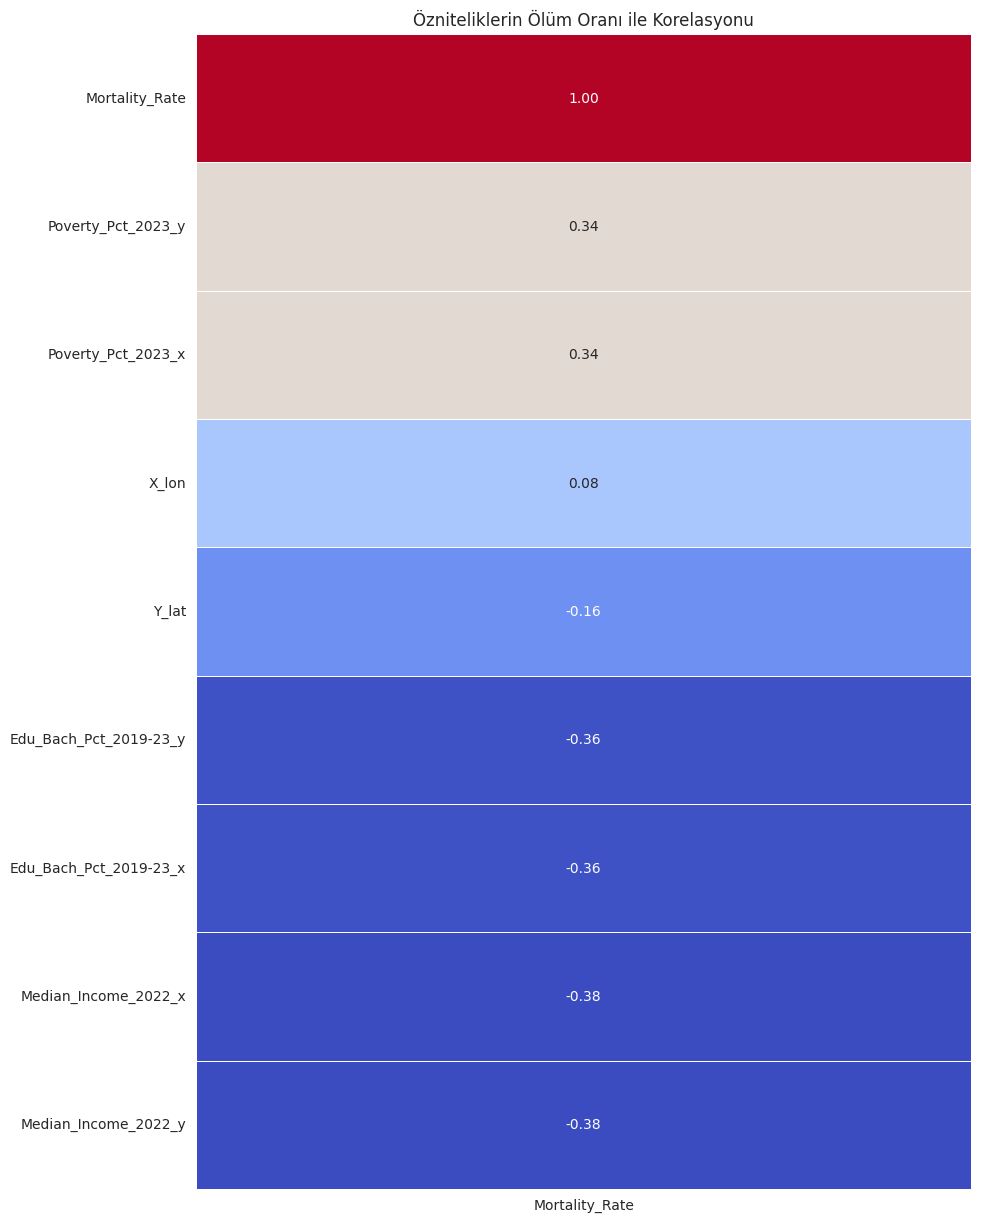

In [ ]:
#  Ölçekleme ve Korelasyon Filtresi
# 4. Veri Ölçekleme (StandardScaler)
scaler = StandardScaler()
X_scaled_array = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled_array, columns=X.columns)
print("Sayısal öznitelikler başarıyla ölçeklendi (StandardScaler).")

# Korelasyon Hesaplama
y_reset = y.reset_index(drop=True)
X_scaled_reset = X_scaled.reset_index(drop=True)
correlation_matrix = pd.concat([X_scaled_reset, y_reset], axis=1).corr()
target_corr = correlation_matrix['Mortality_Rate'].sort_values(ascending=False)

# Korelasyon Isı Haritası (Görselleştirme)
plt.figure(figsize=(10, 15))
sns.heatmap(target_corr.to_frame(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, cbar=False)
plt.title('Özniteliklerin Ölüm Oranı ile Korelasyonu')
plt.show()

    Otomatik olarak en iyi 5 öznitelik seçildi: ['Poverty_Pct_2023_y', 'Poverty_Pct_2023_x', 'X_lon', 'Y_lat', 'Edu_Bach_Pct_2019-23_y']

Korelasyon Eşiği (0.4) kullanılarak seçilen öznitelik sayısı: 5


/tmp/ipython-input-3266516410.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importances.values, y=feature_importances.index, palette='viridis')


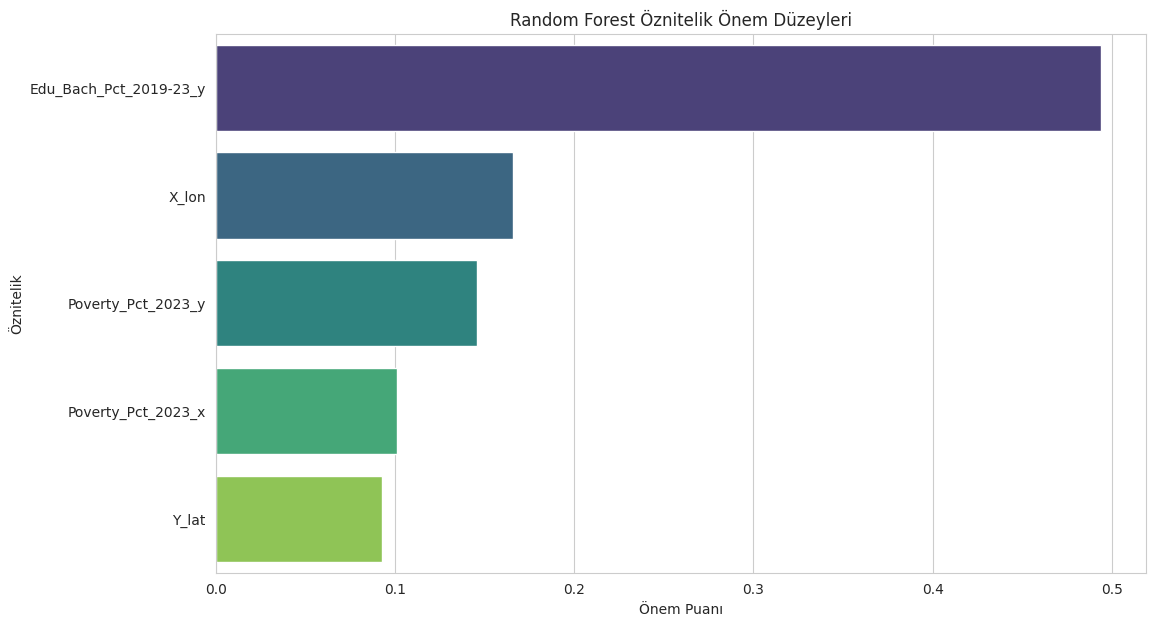


Nihai Öznitelik Kümesi: ['Edu_Bach_Pct_2019-23_y', 'X_lon', 'Poverty_Pct_2023_y', 'Poverty_Pct_2023_x', 'Y_lat']
X_final boyutu: (33030, 5)


In [ ]:
# Random Forest Önemi ve Nihai Özellik Kümesi Seçimi

CORRELATION_THRESHOLD = 0.4
high_corr_features = target_corr[abs(target_corr) > CORRELATION_THRESHOLD].index.tolist()

if 'Mortality_Rate' in high_corr_features:
    high_corr_features.remove('Mortality_Rate')

if len(high_corr_features) == 0:
    high_corr_features = target_corr.index[1:6].tolist()
    print(f"    Otomatik olarak en iyi 5 öznitelik seçildi: {high_corr_features}")

X_filtered = X_scaled[high_corr_features]
print(f"\nKorelasyon Eşiği ({CORRELATION_THRESHOLD}) kullanılarak seçilen öznitelik sayısı: {X_filtered.shape[1]}")

# Random Forest Eğitimi ve Önem Puanı Hesaplama
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, max_depth=5)
rf_model.fit(X_filtered, y)

feature_importances = pd.Series(rf_model.feature_importances_, index=X_filtered.columns)
feature_importances = feature_importances.sort_values(ascending=False)

# Önem Düzeyi Çubuğu Grafiği (Görselleştirme)
plt.figure(figsize=(12, 7))
sns.barplot(x=feature_importances.values, y=feature_importances.index, palette='viridis')
plt.title('Random Forest Öznitelik Önem Düzeyleri')
plt.xlabel('Önem Puanı')
plt.ylabel('Öznitelik')
plt.show()

# Nihai 10 Özellik Seçimi
N_BEST_FEATURES = 10
final_features = feature_importances.head(N_BEST_FEATURES).index.tolist()

X_final = X_scaled[final_features]
print("\nNihai Öznitelik Kümesi:", final_features)
print(f"X_final boyutu: {X_final.shape}")

In [ ]:
# Faz 3'e Geçiş (Veri Bölme)
X_train, X_test, y_train, y_test = train_test_split(
    X_final, y, test_size=0.25, random_state=42
)

print("\n--- FAZ 2 TAMAMLANDI. FAZ 3'E GEÇİLİYOR ---")
print(f"Eğitim Kümesi (X_train) Boyutu: {X_train.shape}")
print(f"Test Kümesi (X_test) Boyutu: {X_test.shape}")


--- FAZ 2 TAMAMLANDI. FAZ 3'E GEÇİLİYOR ---
Eğitim Kümesi (X_train) Boyutu: (24772, 5)
Test Kümesi (X_test) Boyutu: (8258, 5)


In [ ]:
# Kütüphane Yükleme ve Temel Veri Hazırlığı
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

# Sklearn Kütüphaneleri
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

# I. VERİ HAZIRLIĞI
FILE_NAME = "tum_veriler_temiz_birlesmis.csv"
df = pd.read_csv(FILE_NAME)

# Gereksiz Sütunları Çıkarma ve Hedef Değişken Dönüşümü
COLS_TO_DROP_INITIAL = ['State', 'FIPS', 'Georeference']
df_model = df.drop(columns=COLS_TO_DROP_INITIAL, errors='ignore')
threshold = df_model['Mortality_Rate'].median()
df_model['Risk_Class'] = (df_model['Mortality_Rate'] > threshold).astype(int)
df_model = df_model.drop(columns=['Mortality_Rate'])

# One-Hot Encoding ve Boolean (True/False) Düzeltmesi
df_encoded = pd.get_dummies(df_model, drop_first=True)
for col in df_encoded.columns:
    if df_encoded[col].dtype == bool:
        df_encoded[col] = df_encoded[col].astype(int)

# X ve y ayrımı
X = df_encoded.drop(columns=['Risk_Class'])
y = df_encoded['Risk_Class']

print(f"Hedef değişken (Risk_Class) oluşturuldu. Toplam {X.shape[1]} öznitelik hazır.")

Hedef değişken (Risk_Class) oluşturuldu. Toplam 17 öznitelik hazır.


In [ ]:
# Veri Bölme ve Ölçekleme
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# StandardScaler ile ölçekleme
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X.columns)

print(f"Eğitim Kümesi Boyutu: {X_train_scaled_df.shape}")
print(f"Test Kümesi Boyutu: {X_test_scaled_df.shape}")

Eğitim Kümesi Boyutu: (26424, 17)
Test Kümesi Boyutu: (6606, 17)


In [ ]:
# ANOVA Seçimi ve Deney Kurulumu

results = []
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Gaussian Naive Bayes": GaussianNB()
}

scenarios = [
    ("Tüm Özellikler", "all"),
    ("Top 14 Özellik (ANOVA)", 14),
    ("Top 10 Özellik (ANOVA)", 10)
]

best_model_results = {} # En iyi modeli kaydetmek için
f_scores_for_plot = None # F-Score grafiği için veriyi saklamak için

#  Model Eğitim ve Değerlendirme Döngüsü
for scenario_name, k_val in scenarios:

    # Özellik Seçimi (ANOVA Uygulama)
    if k_val == "all":
        X_tr_final = X_train_scaled_df
        X_te_final = X_test_scaled_df
        selected_features = X.columns.tolist()
    else:
        selector = SelectKBest(score_func=f_classif, k=k_val)
        selector.fit(X_train_scaled_df, y_train)

        cols_idxs = selector.get_support(indices=True)
        X_tr_final = X_train_scaled_df.iloc[:, cols_idxs]
        X_te_final = X_test_scaled_df.iloc[:, cols_idxs]
        selected_features = X_tr_final.columns.tolist()

        # Sadece "Top 10 Özellik (ANOVA)" senaryosu için F-Skorlarını kaydetme
        if scenario_name == "Top 10 Özellik (ANOVA)":
            f_scores = selector.scores_[cols_idxs]
            f_scores_for_plot = pd.DataFrame({
                'Feature': selected_features,
                'F-Score': f_scores
            }).sort_values(by='F-Score', ascending=False)


    # Modelleri Eğitme ve Değerlendirme
    for model_name, model in models.items():
        start_time = time.time()
        model.fit(X_tr_final, y_train)
        y_pred = model.predict(X_te_final)
        elapsed = time.time() - start_time

        f1 = f1_score(y_test, y_pred)

        results.append({
            "Senaryo": scenario_name,
            "Model": model_name,
            "Özellik Sayısı": len(selected_features),
            "F1 Score": f1,
            "Süre (sn)": elapsed
        })

        # En iyi modeli kaydetme
        if f1 > best_model_results.get('F1 Score', 0):
            best_model_results = {
                "F1 Score": f1,
                "y_pred": y_pred,
                "model_name": model_name,
                "scenario_name": scenario_name
            }

print(" Deneyler çalıştırıldı ve sonuçlar toplandı.")

 Deneyler çalıştırıldı ve sonuçlar toplandı.



--- PERFORMANS TABLOSU ---
                  Senaryo                 Model  Özellik Sayısı  F1 Score  \
0          Tüm Özellikler   Logistic Regression              17  0.841037   
1          Tüm Özellikler  Gaussian Naive Bayes              17  0.785347   
2  Top 14 Özellik (ANOVA)   Logistic Regression              14  0.812510   
3  Top 14 Özellik (ANOVA)  Gaussian Naive Bayes              14  0.779909   
4  Top 10 Özellik (ANOVA)   Logistic Regression              10  0.796195   
5  Top 10 Özellik (ANOVA)  Gaussian Naive Bayes              10  0.777603   

   Süre (sn)  
0   0.293813  
1   0.043614  
2   0.120980  
3   0.015582  
4   0.148984  
5   0.031908  


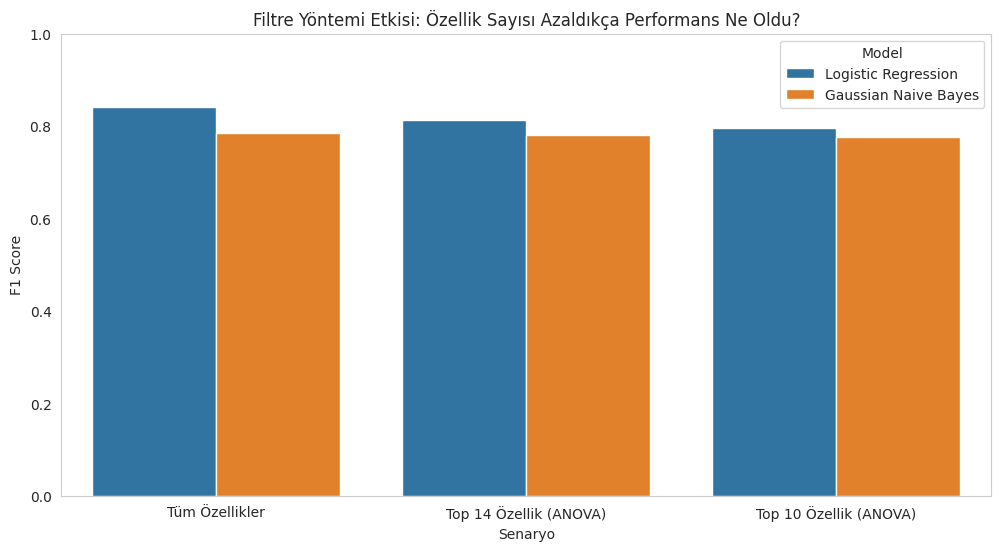

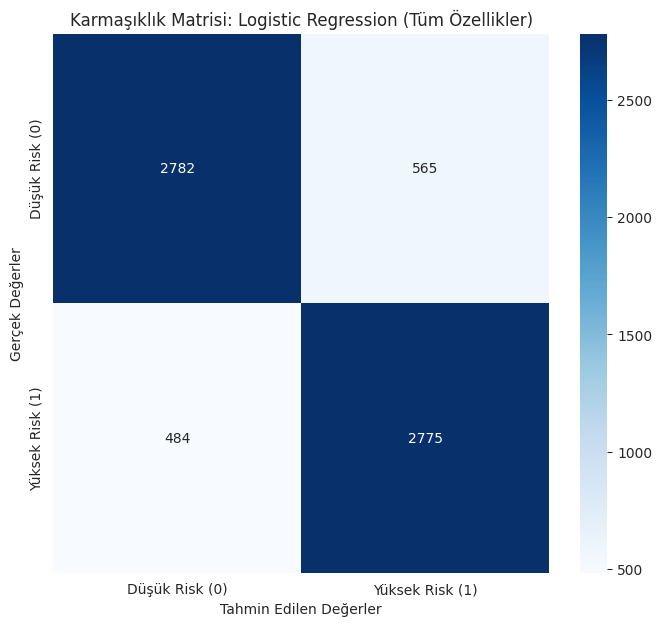

/tmp/ipython-input-2930432282.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='F-Score', y='Feature', data=f_scores_for_plot, palette='Reds_d')


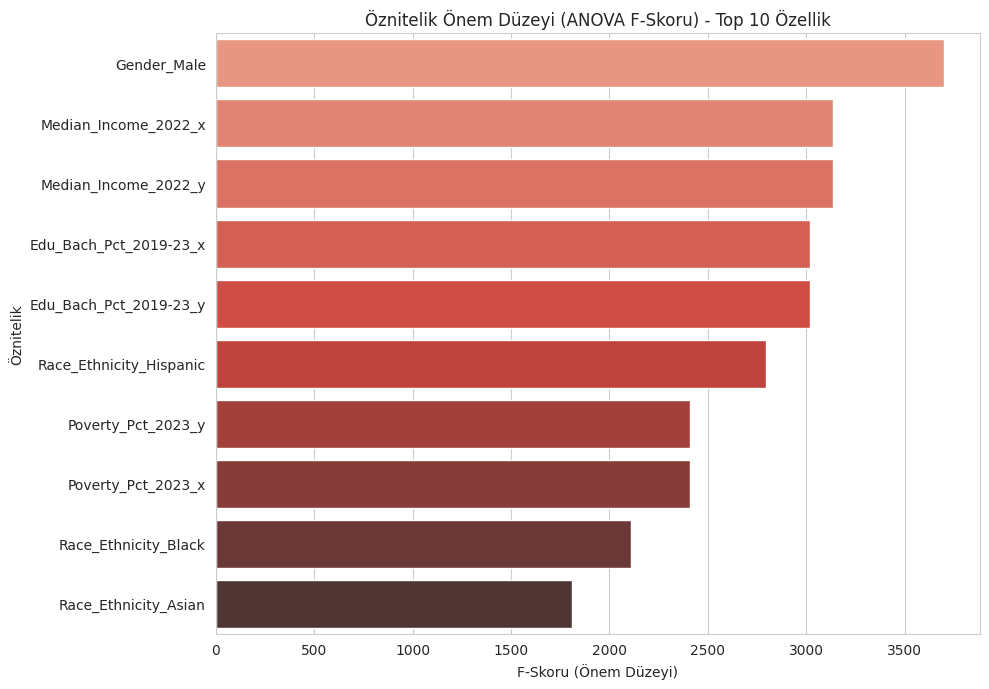


--- FAZ 3 TAMAMLANDI: Tüm Görsel Çıktılar Üretildi ---


In [ ]:
# Raporlama ve Görselleştirme
df_results = pd.DataFrame(results)

print("\n--- PERFORMANS TABLOSU ---")
print(df_results)


# 1. F1 SCORE KARŞILAŞTIRMA GRAFİĞİ
plt.figure(figsize=(12, 6))
sns.barplot(data=df_results, x="Senaryo", y="F1 Score", hue="Model")
plt.title("Filtre Yöntemi Etkisi: Özellik Sayısı Azaldıkça Performans Ne Oldu?")
plt.ylim(0, 1)
plt.grid(axis='y')
plt.show()

# 2. EN İYİ MODEL İÇİN KARMAŞIKLIK MATRİSİ (CONFUSION MATRIX)
cm = confusion_matrix(y_test, best_model_results['y_pred'])

plt.figure(figsize=(8, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Düşük Risk (0)', 'Yüksek Risk (1)'],
            yticklabels=['Düşük Risk (0)', 'Yüksek Risk (1)'])
plt.title(f"Karmaşıklık Matrisi: {best_model_results['model_name']} ({best_model_results['scenario_name']})")
plt.ylabel('Gerçek Değerler')
plt.xlabel('Tahmin Edilen Değerler')
plt.show()

# 3. ÖZELLİK ÖNEM GRAFİĞİ (ANOVA F-SKORU) - Sadece Top 10 için
if f_scores_for_plot is not None:
    plt.figure(figsize=(10, 7))
    sns.barplot(x='F-Score', y='Feature', data=f_scores_for_plot, palette='Reds_d')
    plt.title(f"Öznitelik Önem Düzeyi (ANOVA F-Skoru) - Top 10 Özellik")
    plt.xlabel("F-Skoru (Önem Düzeyi)")
    plt.ylabel("Öznitelik")
    plt.tight_layout()
    plt.show()

print("\n--- FAZ 3 TAMAMLANDI: Tüm Görsel Çıktılar Üretildi ---")

In [9]:
print(" device:", device)
print("X_train_t:", X_train_t.shape, X_train_t.dtype, X_train_t.device)
print("y_train_t:", y_train_t.shape, y_train_t.dtype, y_train_t.device)
print("Train samples:", len(train_loader.dataset))
print("Train batches:", len(train_loader))

xb, yb = next(iter(train_loader))
print("One batch X:", xb.shape, xb.dtype, xb.device)
print("One batch y:", yb.shape, yb.dtype, yb.device, "unique:", torch.unique(yb))


NameError: name 'device' is not defined

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

# ---------- MODEL ----------
class DeepMLP(nn.Module):
    def __init__(self, input_dim, num_classes, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, num_classes)  # logits
        )

    def forward(self, x):
        return self.net(x)

# ---------- CLASS WEIGHTS (optional but good) ----------
# qcut genelde dengeli verir ama yine de güvence olsun
class_counts = y_train.value_counts().sort_index()   # 0,1,2 sırasıyla
weights = (class_counts.sum() / (NUM_CLASSES * class_counts)).values  # inverse frequency
class_weights = torch.tensor(weights, dtype=torch.float32).to(device)

print("⚖️ Class counts:", class_counts.to_dict())
print("⚖️ Class weights:", weights)

# ---------- TRAIN / VALIDATE ----------
def train_one(model, lr=1e-3, max_epochs=200, patience=8):
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss(weight=class_weights)

    best_score = -1.0
    best_state = None
    bad = 0

    for epoch in range(1, max_epochs + 1):
        model.train()
        for xb, yb in train_loader:
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

        # ---- Validation ----
        model.eval()
        with torch.no_grad():
            val_logits = model(X_val_t)
            val_preds = torch.argmax(val_logits, dim=1).cpu().numpy()
            y_val_np = y_val.values if hasattr(y_val, "values") else np.array(y_val)

            val_acc = accuracy_score(y_val_np, val_preds)
            val_f1  = f1_score(y_val_np, val_preds, average="macro")

        # macro-F1 daha adil bir seçim metriği (multi-class)
        score = val_f1

        if epoch % 20 == 0:
            print(f"Epoch {epoch:3d}/{max_epochs} | VAL Acc={val_acc:.4f} | VAL Macro-F1={val_f1:.4f}")

        if score > best_score + 1e-4:
            best_score = score
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            bad = 0
        else:
            bad += 1
            if bad >= patience:
                print(f"⏹️ Early stopping. Best VAL Macro-F1={best_score:.4f}")
                break

    if best_state is not None:
        model.load_state_dict(best_state)
    model.to(device)
    return model, best_score

# ---------- HYPERPARAMETER TUNING ----------
grid = [
    {"lr": 1e-3,  "dropout": 0.2, "epochs": 220},
    {"lr": 5e-4,  "dropout": 0.3, "epochs": 260},
    {"lr": 1e-4,  "dropout": 0.5, "epochs": 320},
]

results = []
best = {"score": -1.0, "cfg": None, "model": None}

print("\n--- TUNING START (DeepMLP - 3-Class Classification) ---")
for cfg in grid:
    set_seed(42)
    model = DeepMLP(INPUT_DIM, NUM_CLASSES, dropout=cfg["dropout"])
    model, best_val_macro_f1 = train_one(model, lr=cfg["lr"], max_epochs=cfg["epochs"], patience=8)

    results.append({
        "lr": cfg["lr"],
        "dropout": cfg["dropout"],
        "epochs": cfg["epochs"],
        "best_val_macro_f1": best_val_macro_f1
    })

    print(f"✅ cfg={cfg} -> BEST VAL Macro-F1={best_val_macro_f1:.4f}")

    if best_val_macro_f1 > best["score"]:
        best = {"score": best_val_macro_f1, "cfg": cfg, "model": model}

tuning_df = pd.DataFrame(results).sort_values("best_val_macro_f1", ascending=False).reset_index(drop=True)
print("\n📌 TUNING TABLE (sorted by VAL Macro-F1):")
print(tuning_df)

# ---------- TEST RESULTS ----------
best_model = best["model"]
best_model.eval()

with torch.no_grad():
    test_logits = best_model(X_test_t)
    y_pred = torch.argmax(test_logits, dim=1).cpu().numpy()

y_test_np = y_test.values if hasattr(y_test, "values") else np.array(y_test)

test_acc = accuracy_score(y_test_np, y_pred)
test_f1_macro = f1_score(y_test_np, y_pred, average="macro")

print("\n🏁 BEST CONFIG:", best["cfg"])
print("--- TEST RESULTS (DeepMLP - 3-Class) ---")
print(f"Accuracy   : {test_acc:.4f}")
print(f"Macro F1   : {test_f1_macro:.4f}")

print("\nClassification Report:")
print(classification_report(
    y_test_np,
    y_pred,
    target_names=["Low", "Medium", "High"]
))

print("Confusion Matrix:")
print(confusion_matrix(y_test_np, y_pred))

⚖️ Class counts: {0: 6611, 1: 6603, 2: 6604}
⚖️ Class weights: [0.99924368 1.00045434 1.00030285]

--- TUNING START (DeepMLP - 3-Class Classification) ---
⏹️ Early stopping. Best VAL Macro-F1=0.7925
✅ cfg={'lr': 0.001, 'dropout': 0.2, 'epochs': 220} -> BEST VAL Macro-F1=0.7925
Epoch  20/260 | VAL Acc=0.7869 | VAL Macro-F1=0.7844
Epoch  40/260 | VAL Acc=0.7958 | VAL Macro-F1=0.7955
⏹️ Early stopping. Best VAL Macro-F1=0.7971
✅ cfg={'lr': 0.0005, 'dropout': 0.3, 'epochs': 260} -> BEST VAL Macro-F1=0.7971
Epoch  20/320 | VAL Acc=0.7688 | VAL Macro-F1=0.7611
Epoch  40/320 | VAL Acc=0.7751 | VAL Macro-F1=0.7693
⏹️ Early stopping. Best VAL Macro-F1=0.7728
✅ cfg={'lr': 0.0001, 'dropout': 0.5, 'epochs': 320} -> BEST VAL Macro-F1=0.7728

📌 TUNING TABLE (sorted by VAL Macro-F1):
       lr  dropout  epochs  best_val_macro_f1
0  0.0005      0.3     260           0.797075
1  0.0010      0.2     220           0.792499
2  0.0001      0.5     320           0.772778

🏁 BEST CONFIG: {'lr': 0.0005, 'drop

🧾 X shape: (33030, 66) | y distribution:
Mortality_Class
0    11019
2    11006
1    11005
Name: count, dtype: int64

--- TUNING START (RandomForestClassifier) ---
✅ cfg={'n_estimators': 200, 'max_depth': None, 'min_samples_split': 2, 'max_features': 'sqrt'} -> VAL Acc=0.8009 | VAL Macro-F1=0.8012
✅ cfg={'n_estimators': 400, 'max_depth': 20, 'min_samples_split': 2, 'max_features': 'sqrt'} -> VAL Acc=0.7997 | VAL Macro-F1=0.8000
✅ cfg={'n_estimators': 400, 'max_depth': None, 'min_samples_split': 5, 'max_features': 'sqrt'} -> VAL Acc=0.8028 | VAL Macro-F1=0.8027

📌 TUNING TABLE (sorted by VAL Macro-F1):
   n_estimators  max_depth  min_samples_split max_features  val_accuracy  \
0           400        NaN                  5         sqrt      0.802755   
1           200        NaN                  2         sqrt      0.800939   
2           400       20.0                  2         sqrt      0.799728   

   val_f1_macro  
0      0.802709  
1      0.801243  
2      0.800003  

🏁 BEST CONFIG 

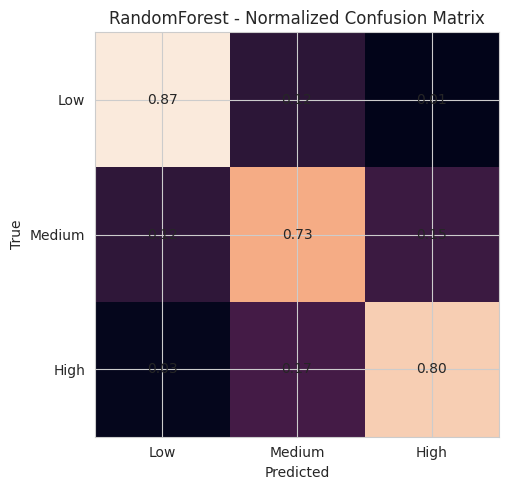


ROC-AUC (OvR, macro): 0.9312


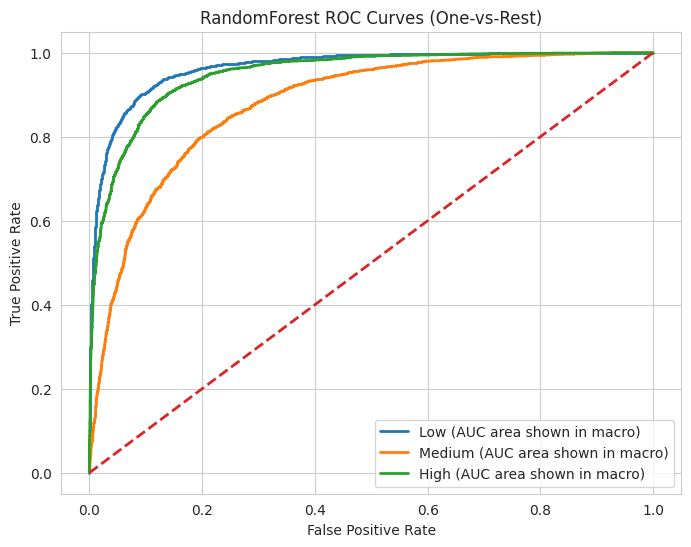

In [ ]:
# ===== MODEL 2: RandomForestClassifier (Ensemble) - 3-Class Classification =====
# Target: Mortality_Class (Low/Medium/High) from Mortality_Rate via quantiles

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    f1_score, roc_auc_score, roc_curve
)
from sklearn.preprocessing import label_binarize
from sklearn.ensemble import RandomForestClassifier

# ------------------ 1) LOAD DATA ------------------
DATA_PATH = "/content/tum_veriler_temiz_birlesmis.csv"
df = pd.read_csv(DATA_PATH).dropna()

# ------------------ 2) CREATE CLASS TARGET ------------------
df["Mortality_Class"] = pd.qcut(
    df["Mortality_Rate"],
    q=3,
    labels=[0, 1, 2]  # 0=Low, 1=Medium, 2=High
).astype(int)

y = df["Mortality_Class"]
X = df.drop(columns=["Mortality_Rate", "Mortality_Class"])

# ------------------ 3) FEATURE ENGINEERING ------------------
X = X.drop(columns=["Georeference"], errors="ignore")
X = X.drop(columns=["FIPS"], errors="ignore")

X = pd.get_dummies(
    X,
    columns=["State", "Gender", "Race_Ethnicity"],
    drop_first=True
)

print("🧾 X shape:", X.shape, "| y distribution:")
print(y.value_counts())

# ------------------ 4) SPLIT ------------------
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.25, random_state=42, stratify=y_trainval
)

# IMPORTANT: RandomForest doesn't need scaling
X_train_s, X_val_s, X_test_s = X_train, X_val, X_test

# ------------------ 5) HYPERPARAMETER TUNING (mini grid) ------------------
param_grid = [
    {"n_estimators": 200, "max_depth": None, "min_samples_split": 2, "max_features": "sqrt"},
    {"n_estimators": 400, "max_depth": 20,   "min_samples_split": 2, "max_features": "sqrt"},
    {"n_estimators": 400, "max_depth": None, "min_samples_split": 5, "max_features": "sqrt"},
]

results = []
best = {"score": -1, "cfg": None, "model": None}

print("\n--- TUNING START (RandomForestClassifier) ---")
for cfg in param_grid:
    rf = RandomForestClassifier(
        n_estimators=cfg["n_estimators"],
        max_depth=cfg["max_depth"],
        min_samples_split=cfg["min_samples_split"],
        max_features=cfg["max_features"],
        class_weight="balanced",   # ✅ makes it more robust even if qcut isn't perfectly balanced
        random_state=42,
        n_jobs=-1
    )
    rf.fit(X_train_s, y_train)

    val_pred = rf.predict(X_val_s)
    val_acc = accuracy_score(y_val, val_pred)
    val_f1_macro = f1_score(y_val, val_pred, average="macro")

    results.append({**cfg, "val_accuracy": val_acc, "val_f1_macro": val_f1_macro})
    print(f"✅ cfg={cfg} -> VAL Acc={val_acc:.4f} | VAL Macro-F1={val_f1_macro:.4f}")

    # choose by Macro-F1 (more fair in multiclass)
    if val_f1_macro > best["score"]:
        best = {"score": val_f1_macro, "cfg": cfg, "model": rf}

tuning_df = pd.DataFrame(results).sort_values("val_f1_macro", ascending=False).reset_index(drop=True)
print("\n📌 TUNING TABLE (sorted by VAL Macro-F1):")
print(tuning_df)

# ------------------ 6) TEST RESULTS ------------------
best_model = best["model"]
test_pred = best_model.predict(X_test_s)

test_acc = accuracy_score(y_test, test_pred)
test_f1_macro = f1_score(y_test, test_pred, average="macro")
cm = confusion_matrix(y_test, test_pred)

print("\n🏁 BEST CONFIG (RandomForest):", best["cfg"])
print("--- TEST RESULTS (RandomForest) ---")
print(f"Accuracy : {test_acc:.4f}")
print(f"Macro-F1 : {test_f1_macro:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, test_pred, target_names=["Low", "Medium", "High"]))
print("Confusion Matrix:")
print(cm)

# ------------------ 7) NORMALIZED CONFUSION MATRIX PLOT (Rapora koymalık) ------------------
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(6,5))
plt.imshow(cm_norm, interpolation="nearest")
plt.title("RandomForest - Normalized Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks([0,1,2], ["Low","Medium","High"])
plt.yticks([0,1,2], ["Low","Medium","High"])

for i in range(3):
    for j in range(3):
        plt.text(j, i, f"{cm_norm[i, j]:.2f}", ha="center", va="center")

plt.tight_layout()
plt.show()

# ------------------ 8) ROC-AUC (One-vs-Rest) + ROC CURVE (bonus, very good for report) ------------------
# Multiclass ROC AUC needs probability estimates
probs = best_model.predict_proba(X_test_s)  # shape (N, 3)
y_test_bin = label_binarize(y_test, classes=[0,1,2])  # shape (N, 3)

auc_ovr = roc_auc_score(y_test_bin, probs, multi_class="ovr", average="macro")
print(f"\nROC-AUC (OvR, macro): {auc_ovr:.4f}")

# Plot ROC curve for each class
plt.figure(figsize=(8,6))
for c, name in zip([0,1,2], ["Low","Medium","High"]):
    fpr, tpr, _ = roc_curve(y_test_bin[:, c], probs[:, c])
    plt.plot(fpr, tpr, lw=2, label=f"{name} (AUC area shown in macro)")

plt.plot([0,1], [0,1], lw=2, linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("RandomForest ROC Curves (One-vs-Rest)")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

Bağlantı kontrol ediliyor...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dosya başarıyla bulundu: /content/drive/MyDrive/tum_veriler_temiz_birlesmis.csv

 KALP KRİZİ RİSKİ EN YÜKSEK 10 EYALET:
State
MS    0.703145
AL    0.660057
AR    0.616644
OK    0.612319
LA    0.601449
KY    0.571575
TN    0.551402
WV    0.493976
GA    0.467972
MO    0.463389
Name: Yüksek, dtype: float64


/tmp/ipython-input-2835829052.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=top_15.index, y=top_15.values, palette="Reds_r")


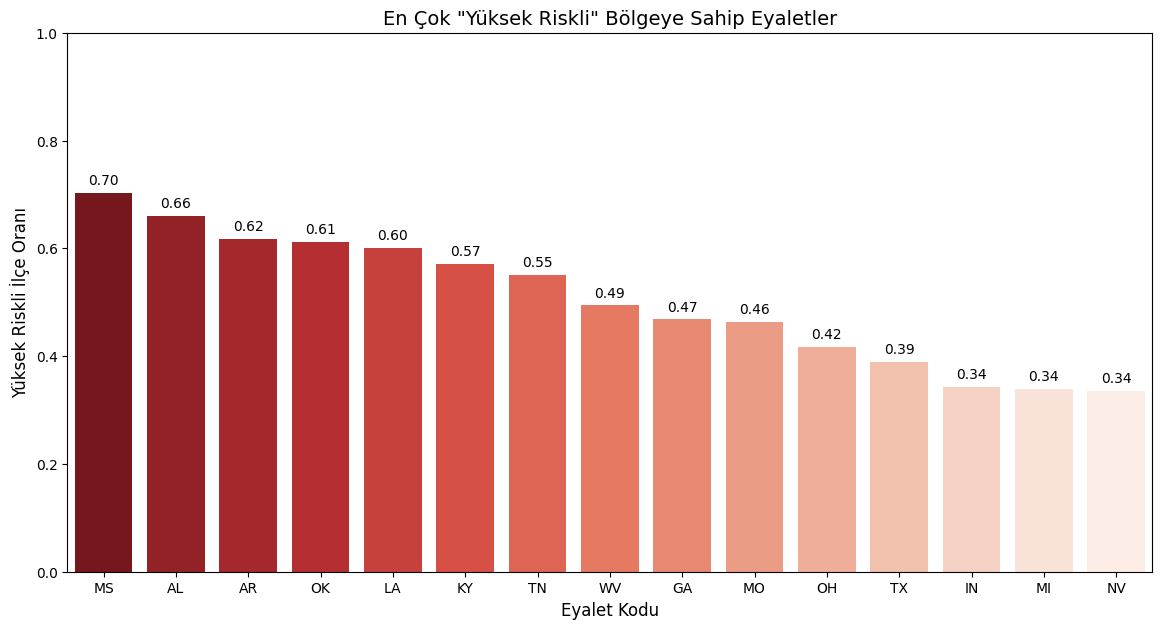

In [8]:
# --- BAĞLANTI KOPUNCA ÇALIŞTIRILACAK TAM KOD ---
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
import os

# 1. Drive'ı Tekrar Bağla (İzin ver penceresi açılırsa onaylayın)
print("Bağlantı kontrol ediliyor...")
drive.mount('/content/drive')

# 2. Dosya Yolunu Bul (Dosyanın Drive ana sayfasında olduğunu varsayıyoruz)
dosya_yolu = "/content/drive/MyDrive/tum_veriler_temiz_birlesmis.csv"

if os.path.exists(dosya_yolu):
    print(f"Dosya başarıyla bulundu: {dosya_yolu}")

    # Veriyi Oku
    df = pd.read_csv(dosya_yolu)

    # 3. Analizi Yap (Hangi Eyalet Daha Riskli?)
    # Risk seviyesini oluştur (Düşük/Orta/Yüksek)
    if 'Risk_Level' not in df.columns:
        df['Risk_Level'] = pd.qcut(df['Mortality_Rate'], q=3, labels=['Düşük', 'Orta', 'Yüksek'])

    # Eyaletlere göre risk oranlarını hesapla
    eyalet_riski = pd.crosstab(df['State'], df['Risk_Level'], normalize='index')

    # En yüksek riskli eyaletleri sırala
    en_riskli_eyaletler = eyalet_riski['Yüksek'].sort_values(ascending=False)

    print("\n KALP KRİZİ RİSKİ EN YÜKSEK 10 EYALET:")
    print(en_riskli_eyaletler.head(10))

    # 4. Grafiği Çiz
    plt.figure(figsize=(14, 7))
    top_15 = en_riskli_eyaletler.head(15)
    ax = sns.barplot(x=top_15.index, y=top_15.values, palette="Reds_r")

    plt.title('En Çok "Yüksek Riskli" Bölgeye Sahip Eyaletler', fontsize=14)
    plt.xlabel('Eyalet Kodu', fontsize=12)
    plt.ylabel('Yüksek Riskli İlçe Oranı', fontsize=12)
    plt.ylim(0, 1)

    # Barların üzerine oranları yaz
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.2f}',
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center', xytext=(0, 9), textcoords='offset points')

    plt.show()

else:
    print(f" HATA: '{dosya_yolu}' bulunamadı.")
    print("İPUCU: Dosyanız Drive'ın içinde bir klasördeyse (örn: 'Dersler'), dosya yolunu şöyle düzeltin:")
    print('dosya_yolu = "/content/drive/MyDrive/Dersler/tum_veriler_temiz_birlesmis.csv"')

In [6]:
from google.colab import drive
drive.mount('/content/drive')

KeyboardInterrupt: 